In [1]:
# -----------------------------------------------------------
#  VWAP Breakout Strategy • intraday • backtesting.py
# -----------------------------------------------------------
import pandas as pd
import numpy as np
from datetime import time
from backtesting import Backtest, Strategy

def add_vwap(
    df: pd.DataFrame,
    time_col: str | None = None,
    price_col: str = "Close",
    vol_col: str = "Volume",
    **parse_kwargs                # ← forwarded to pd.to_datetime
) -> pd.DataFrame:
    df = df.copy()

    # 1 ─ ensure DatetimeIndex
    if time_col is not None:
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce", **parse_kwargs)
        df = df.set_index(time_col)

    if not isinstance(df.index, pd.DatetimeIndex) or df.index.hasnans:
        raise TypeError("Index (or `time_col`) must be datetime-like and parse without NaT")

    # 2 ─ price to weight by volume
    tp = ((df["High"] + df["Low"] + df["Close"]) / 3) if price_col.lower() == "typical" else df[price_col]

    # 3 ─ VWAP per calendar day
    day = df.index.normalize()
    cum_vol = df[vol_col].groupby(day).cumsum()
    cum_pv  = (tp * df[vol_col]).groupby(day).cumsum()
    df["VWAP"] = cum_pv / cum_vol
    return df

f:\Python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def add_weekly_vwap(
    df: pd.DataFrame,
    *,
    time_col: str | None = None,
    price_col: str = "Close",
    vol_col:   str = "Volume",
    freq:      str = "D",           # "D" (daily) or "W-MON", "W-FRI", …
    **parse_kwargs,                 # forwarded to pd.to_datetime
) -> pd.DataFrame:
    """
    Append a VWAP column that resets every *freq* period.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain `price_col`, `vol_col`, and (optionally) High/Low if
        price_col="Typical".
    time_col : str | None
        Pass the name of the timestamp column if the index is not already
        Datetime-like.
    price_col : {"Close", "Typical", ...}
        Price to weight by volume.  "Typical" uses (High+Low+Close)/3.
    vol_col : str
        Volume column name.
    freq : str, default "D"
        Pandas offset alias that defines VWAP reset boundary.
        Examples: "D" (daily), "W-MON" (weekly ending Monday), "M" (monthly).
    **parse_kwargs
        Extra arguments passed to `pd.to_datetime` when parsing `time_col`.

    Returns
    -------
    pd.DataFrame
        Copy of `df` with an added 'VWAP' column.
    """
    df = df.copy()

    # -- 1. ensure DatetimeIndex --------------------------------------------
    if time_col is not None:
        df[time_col] = pd.to_datetime(df[time_col], errors="coerce", **parse_kwargs)
        df = df.set_index(time_col)

    if not isinstance(df.index, pd.DatetimeIndex) or df.index.hasnans:
        raise TypeError("Index (or `time_col`) must be datetime-like and parse without NaT")

    # -- 2. choose the price series -----------------------------------------
    if price_col.lower() == "typical":
        tp = (df["High"] + df["Low"] + df["Close"]) / 3
    else:
        tp = df[price_col]

    # -- 3. labels defining each VWAP bucket --------------------------------
    # floor to the start of each period (e.g. Monday 00:00 if freq="W-MON")
    labels = df.index.to_period(freq).to_timestamp()

    # cumulative sums within each period
    cum_vol = df[vol_col].groupby(labels).cumsum()
    cum_pv  = (tp * df[vol_col]).groupby(labels).cumsum()

    df["VWAP"] = cum_pv / cum_vol
    return df


In [3]:

# -------- 3. strategy --------------------------------------
class VWAPBreakout(Strategy):
    """
    • Long  when Close crosses above VWAP
    • Short when Close crosses below VWAP
    Optional filter: take longs only if Close > day’s Open (bull bias)
    Always flat by 15:45‒16:00 ET bar
    """

    # --- configurable parameters (can be optimised) --------
    intraday_close_time = time(15, 45)  # last bar before close (interval = 15m)
    atr_stop = 1.5  # e.g. 1.5 to use ATR trailing stop, None = no stop

    def init(self):
        # pre-compute ATR if a trailing stop is requested
        if self.atr_stop:
            self.atr = self.I(self._atr, self.data.High, self.data.Low, self.data.Close, 14)

    # ---- utility: ATR (simple True Range MA)
    @staticmethod
    def _atr(h, l, c, n):
        tr = np.maximum.reduce([h[1:] - l[1:], abs(h[1:] - c[:-1]), abs(l[1:] - c[:-1])])
        atr = pd.Series(tr).rolling(n).mean()
        return np.append([np.nan], atr)  # align length

    # -------------------------------------------------------
    def next(self):
        #i = len(self.data.Close) - 1  # current bar index

        close = self.data.Close[-1]
        vwap  = self.data.VWAP[-1]

        # --- determine daily open price for filters ----------
        current_day = self.data.index[-1].date()
        day_open = self.data.Open[self.data.index.date == current_day][0]

        # -------- entry logic --------------------------------
        if not self.position:

            # LONG
            if (close > vwap) and (close > day_open): #and close>self.data.Open[-1]
                self.buy()

            # SHORT
            elif (close < vwap) and (close < day_open): # and close<self.data.Open[-1]
                self.sell()

        if self.position and self.atr_stop:          # <-- note lower-case .position
            price = self.data.Close[-1]     
            atr = self.atr[-1]
            trail = self.atr_stop * atr

            # tighten stop on every active trade
            for trade in self.trades:
                if trade.is_long:
                    new_sl = price - trail
                    if trade.sl is None or new_sl > trade.sl:
                        trade.sl = new_sl
                else:                      # short trade
                    new_sl = price + trail
                    if trade.sl is None or new_sl < trade.sl:
                        trade.sl = new_sl

        # -------- intraday exit: flatten before close --------
        if self.position:
            bar_time = self.data.index[-1].time()
            if bar_time >= self.intraday_close_time:
                self.position.close()

Start                     2022-08-24 16:30:00
End                       2023-04-05 18:30:00
Duration                    224 days 02:00:00
Exposure Time [%]                      81.325
Equity Final [$]                238773.977143
Equity Peak [$]                 240909.573143
Return [%]                         138.773977
Buy & Hold Return [%]              -79.374058
Return (Ann.) [%]                  311.655282
Volatility (Ann.) [%]              193.273927
Sharpe Ratio                         1.612506
Sortino Ratio                       13.588995
Calmar Ratio                         22.05838
Max. Drawdown [%]                  -14.128657
Avg. Drawdown [%]                   -1.912063
Max. Drawdown Duration       28 days 00:15:00
Avg. Drawdown Duration        2 days 13:42:00
# Trades                                 1285
Win Rate [%]                        49.727626
Best Trade [%]                       8.821076
Worst Trade [%]                     -4.649091
Avg. Trade [%]                    

f:\Python\Lib\site-packages\backtesting\_plotting.py:250: UserWarning: DatetimeFormatter scales now only accept a single format. Using the first provided: '%d %b'
  formatter=DatetimeTickFormatter(days=['%d %b', '%a %d'],
f:\Python\Lib\site-packages\backtesting\_plotting.py:250: UserWarning: DatetimeFormatter scales now only accept a single format. Using the first provided: '%m/%Y'
  formatter=DatetimeTickFormatter(days=['%d %b', '%a %d'],
f:\Python\Lib\site-packages\backtesting\_plotting.py:456: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample(resample_rule, label='left')
f:\Python\Lib\site-packages\backtesting\_plotting.py:659: UserWarning: found multiple competing values for 'toolbar.active_drag' property; using the latest value
  fig = gridplot(
f:\Python\Lib\site-packages\backtesting\_plotting.py:659: UserWarning: found multiple competing values for 'toolbar.active_scroll' property; using the latest value
  fig = gridplo

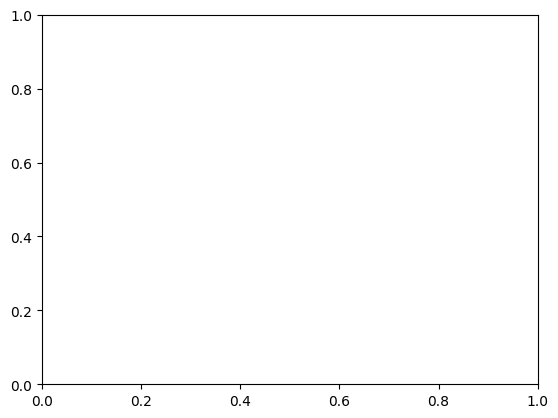

In [ ]:
#df = pd.read_csv("TSLA.USUSD_Candlestick_15_M_BID_01.06.2024-28.06.2025.csv")
#df = pd.read_csv("BTCUSD_Candlestick_15_M_BID_01.06.2024-28.06.2025.csv")
#df = pd.read_csv("AAPL.USUSD_Candlestick_1_D_BID_01.06.2020-28.06.2025.csv")
df = pd.read_csv("TSLA.USUSD_Candlestick_15_M_BID_30.06.2022-28.06.2025.csv")
df = add_vwap(
            df,
            time_col="Gmt time",
            dayfirst=True,                         # parses 03.06.2024 correctly
            format="%d.%m.%Y %H:%M:%S.%f"          # speeds up parsing, too
            )
# df = add_weekly_vwap(
#         df[100:],
#         time_col="Gmt time",               # ← let the helper parse & index it
#         dayfirst=True,                     # 03.06.2024 = 3 June 2024
#         format="%d.%m.%Y %H:%M:%S.%f",     # exact pattern = faster/no NaT
#         freq="W-FRI"                       # weekly VWAP, week ends Friday
# )

bt = Backtest(
    df[1000:5000],
    VWAPBreakout,
    cash=100_000,
    commission=0.000,  # e.g. 0.001 for 0.1% commission
    exclusive_orders=True,  # only one position at a time
    trade_on_close=True,    # act on bar close prices
)

import matplotlib.pyplot as plt

stats = bt.run()
print(stats)       # show key stats
bt.plot(show_legend=False)


In [7]:
# --------------------------------------------------------
# Sweep atr_stop from 0.5 to 3.0 in 0.25 steps
# --------------------------------------------------------
stats_best, heatmap = bt.optimize(
    atr_stop = [round(x, 2) for x in np.arange(1, 2.51, 0.25)],
    maximize = "Sharpe Ratio",
    return_heatmap = True,      # keep all runs, not just the best
)

# ------------ best run ------------
best_atr  = stats_best._strategy.atr_stop
best_ret  = stats_best["Return [%]"]
best_sharpe = stats_best["Sharpe Ratio"]

print("=== Best parameter set ===")
print(f"atr_stop      : {best_atr:.2f}")
print(f"Return [%]    : {best_ret:.2f}")
print(f"Sharpe Ratio  : {best_sharpe:.2f}")


=== Best parameter set ===
atr_stop      : 1.50
Return [%]    : 713.26
Sharpe Ratio  : 0.90


In [ ]:
# ------------ all runs ------------
# heatmap is a Series (single parameter) whose index is atr_stop
summary = (
    heatmap
    .rename("Sharpe Ratio")      # put metric in a column
    .reset_index()               # bring atr_stop out of the index
    .rename(columns={"index": "atr_stop"})
    .sort_values("atr_stop")
)

# For cumulative return we need to run once per value;
# easiest: loop over summary index and pull the stat from bt.run()
returns = []
for val in summary["atr_stop"]:
    res = bt.run(atr_stop=val)
    returns.append(res["Return [%]"])
summary["Return [%]"] = returns

print("\n=== Full sweep results ===")
print(summary.to_string(index=False))


=== Full sweep results ===
 atr_stop  Sharpe Ratio  Return [%]
     1.00      0.805325  505.003855
     1.25      0.672918  330.088005
     1.50      0.896165  714.445055
     1.75      0.793969  496.073129
     2.00      0.715064  371.965649
     2.25      0.637745  282.627629
     2.50      0.620951  266.774319


In [6]:
bt.plot()

f:\Python\Lib\site-packages\backtesting\_plotting.py:122: UserWarning: Data contains too many candlesticks to plot; downsampling to '4H'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "
f:\Python\Lib\site-packages\backtesting\_plotting.py:126: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample(freq, label='right').agg(OHLCV_AGG).dropna()
f:\Python\Lib\site-packages\backtesting\_plotting.py:128: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  indicators = [_Indicator(i.df.resample(freq, label='right').mean()
f:\Python\Lib\site-packages\backtesting\_plotting.py:136: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  equity_data = equity_data.resample(freq, label='right').agg(_EQUITY_AGG).dropna(how='all')
f:\Python\Lib\site-packages\backtesting\_pl

ValueError: Length of values (10) does not match length of index (5)